# Backpropagation: From Scratch to PyTorch

In this worksheet we will:
1. Understand **what gradients are** and why we need them for training neural networks
2. Implement the **naive (slow) way** to compute gradients
3. Implement **backpropagation** — the efficient way
4. Train a simple feedforward neural network using our manual backprop
5. See how **PyTorch autograd** does all of this for us

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

---
## Part 1: Why Do We Need Gradients?

Recall the training loop for a neural network using **Stochastic Gradient Descent (SGD)**:

$$\theta = \theta - \eta \cdot \nabla_\theta \mathcal{L}$$

where $\theta$ are all trainable parameters ($W^{[1]}, W^{[2]}, \alpha, b$), $\eta$ is the learning rate, and $\nabla_\theta \mathcal{L}$ is the **gradient** of the loss with respect to every parameter.

**The gradient tells us:** for each parameter, which direction should we nudge it to decrease the loss, and by how much?

### A simple example: gradient of a scalar function

Let's start with a simple function $f(x) = x^2$ and compute its gradient at a point.

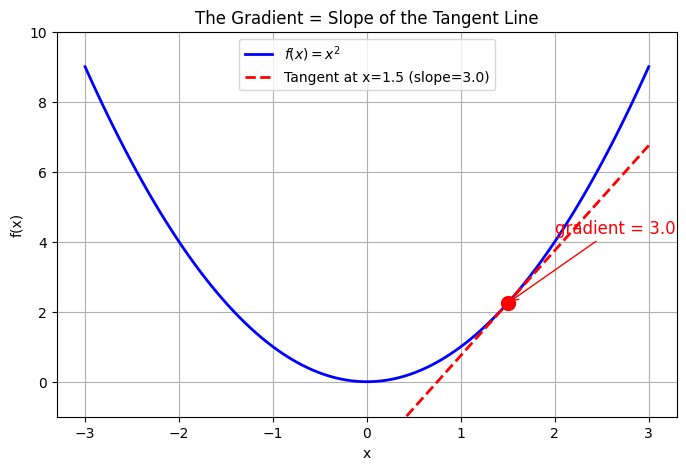

At x = 1.5:
  f(x)  = 2.25
  f'(x) = 3.0
  => To DECREASE f, move x in the NEGATIVE gradient direction (to the left)


In [2]:
# Visualize the gradient as the slope of the tangent line
x_vals = np.linspace(-3, 3, 100)
f_vals = x_vals ** 2

# Pick a point
x0 = 1.5
f_x0 = x0 ** 2
grad_x0 = 2 * x0  # df/dx = 2x

# Tangent line: f(x0) + grad * (x - x0)
tangent = f_x0 + grad_x0 * (x_vals - x0)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, f_vals, 'b-', linewidth=2, label='$f(x) = x^2$')
plt.plot(x_vals, tangent, 'r--', linewidth=2, label=f'Tangent at x={x0} (slope={grad_x0})')
plt.plot(x0, f_x0, 'ro', markersize=10)
plt.ylim(-1, 10)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('The Gradient = Slope of the Tangent Line')
plt.legend()
plt.grid(True)
plt.annotate(f'gradient = {grad_x0}', xy=(x0, f_x0), xytext=(x0+0.5, f_x0+2),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=12, color='red')
plt.show()

print(f"At x = {x0}:")
print(f"  f(x)  = {f_x0}")
print(f"  f'(x) = {grad_x0}")
print(f"  => To DECREASE f, move x in the NEGATIVE gradient direction (to the left)")

---
## Part 2: The Naive Way to Compute Gradients (Numerical Differentiation)

The simplest way to compute a gradient is using the **finite difference** approximation:

$$\frac{\partial f}{\partial \theta_i} \approx \frac{f(\theta_i + \epsilon) - f(\theta_i - \epsilon)}{2\epsilon}$$

This is easy to implement, but **very slow** for neural networks. Why?
- If we have $P$ parameters, we need $2P$ forward passes (one +$\epsilon$ and one -$\epsilon$ for each parameter)
- For a network with millions of parameters, this is completely impractical!

### Let's see this in action on a simple network

We'll build a tiny 2-layer feedforward network:
- Input: 2 features
- Hidden layer: 3 neurons with ReLU
- Output: 1 neuron (regression)

$$h(x) = \alpha^\top \text{ReLU}(W^{[2]} \cdot \text{ReLU}(W^{[1]} x)) + b$$

In [3]:
# Define our simple network as plain numpy/torch operations (NO autograd yet)
# Network: input(2) -> hidden1(3) -> hidden2(3) -> output(1)

def relu(z):
    """ReLU activation: max(0, z)"""
    return torch.clamp(z, min=0)

def forward(x, W1, W2, alpha, b):
    """
    Forward pass of a 2-hidden-layer FNN.
    
    x:     input vector (2,)
    W1:    weights for layer 1 (3, 2)
    W2:    weights for layer 2 (3, 3)
    alpha: output weights (3,)
    b:     output bias (scalar)
    
    Returns: scalar prediction y_hat
    """
    z1 = relu(W1 @ x)        # hidden layer 1: (3,)
    z2 = relu(W2 @ z1)       # hidden layer 2: (3,)
    y_hat = alpha @ z2 + b   # output: scalar
    return y_hat

def mse_loss(y_hat, y):
    """Mean squared error loss for a single sample: (y_hat - y)^2"""
    return (y_hat - y) ** 2

# Initialize parameters
W1 = torch.randn(3, 2)
W2 = torch.randn(3, 3)
alpha = torch.randn(3)
b = torch.zeros(1)

# A single training example
x = torch.tensor([1.0, 2.0])
y = torch.tensor(3.0)

# Forward pass
y_hat = forward(x, W1, W2, alpha, b)
loss = mse_loss(y_hat, y)
print(f"Input x     = {x}")
print(f"Target y    = {y}")
print(f"Prediction  = {y_hat.item():.4f}")
print(f"Loss        = {loss.item():.4f}")

Input x     = tensor([1., 2.])
Target y    = 3.0
Prediction  = 1.5340
Loss        = 2.1491


### Numerical Gradient Computation

Now let's compute gradients the **naive** way: perturb each parameter by $\pm\epsilon$ and measure how the loss changes.

In [4]:
def numerical_gradient(params, x, y, epsilon=1e-5):
    """
    Compute gradients numerically using finite differences.
    
    For EACH scalar parameter theta_i:
        grad_i = (loss(theta_i + eps) - loss(theta_i - eps)) / (2 * eps)
    
    This requires 2 forward passes PER PARAMETER.
    """
    grads = []
    forward_pass_count = 0
    
    for p_idx, param in enumerate(params):
        param_grad = torch.zeros_like(param)
        
        # Iterate over every single scalar element in this parameter
        for idx in range(param.numel()):
            # Flatten, perturb one element, reshape back
            original_val = param.view(-1)[idx].item()
            
            # f(theta + epsilon)
            param.view(-1)[idx] = original_val + epsilon
            y_hat_plus = forward(x, *params)
            loss_plus = mse_loss(y_hat_plus, y)
            forward_pass_count += 1
            
            # f(theta - epsilon)
            param.view(-1)[idx] = original_val - epsilon
            y_hat_minus = forward(x, *params)
            loss_minus = mse_loss(y_hat_minus, y)
            forward_pass_count += 1
            
            # Finite difference
            param_grad.view(-1)[idx] = (loss_plus - loss_minus) / (2 * epsilon)
            
            # Restore original value
            param.view(-1)[idx] = original_val
        
        grads.append(param_grad)
    
    return grads, forward_pass_count

# Compute numerical gradients
params = [W1, W2, alpha, b]
num_grads, num_fwd = numerical_gradient(params, x, y)

total_params = sum(p.numel() for p in params)
print(f"Total parameters: {total_params}")
print(f"Forward passes needed: {num_fwd}")
print(f"That's 2 x {total_params} = {2 * total_params} forward passes!\n")

param_names = ['W1', 'W2', 'alpha', 'b']
for name, grad in zip(param_names, num_grads):
    print(f"d(loss)/d({name}):")
    print(f"  {grad}\n")

Total parameters: 19
Forward passes needed: 38
That's 2 x 19 = 38 forward passes!

d(loss)/d(W1):
  tensor([[ -7.2718, -14.4720],
        [ -0.2980,  -0.5603],
        [  0.0000,   0.0000]])

d(loss)/d(W2):
  tensor([[-1.6809, -1.9431,  0.0000],
        [-2.3246, -2.6941,  0.0000],
        [ 0.0000,  0.0000,  0.0000]])

d(loss)/d(alpha):
  tensor([-2.5511, -1.5736,  0.0000])

d(loss)/d(b):
  tensor([-2.9325])



### The Problem with Numerical Gradients

| Network Size | Parameters | Forward Passes Needed |
|---|---|---|
| Our tiny network | 22 | 44 |
| Small MLP (784->256->10) | ~203K | ~406K |
| ResNet-50 | ~25.6M | ~51.2M |
| GPT-3 | ~175B | ~350B |

**This is $O(P)$ forward passes**, where $P$ is the number of parameters. Each forward pass itself costs $O(\text{size of graph})$.

**Total cost: $O(P \times \text{size of graph})$** — essentially $O(\text{graph}^2)$ for typical networks.

**Can we do better?** Yes! Backpropagation computes ALL gradients in just **1 forward + 1 backward pass** = $O(\text{size of graph})$.

---
## Part 3: Backpropagation — The Efficient Way

### The Key Insight

In the naive approach, when computing $\frac{\partial \hat{y}}{\partial w_1}$ and $\frac{\partial \hat{y}}{\partial w_2}$, we **recompute the same chain of derivatives** from the output backwards. Backprop avoids this by:

1. **Forward pass**: compute all intermediate values $z_1, z_2, \ldots$ and store them
2. **Backward pass**: starting from the loss, propagate gradients **backwards** through the network, **reusing** computations

For our network:
$$x \xrightarrow{W^{[1]}} z_1 = \text{ReLU}(W^{[1]}x) \xrightarrow{W^{[2]}} z_2 = \text{ReLU}(W^{[2]}z_1) \xrightarrow{\alpha} \hat{y} = \alpha^\top z_2 + b$$

**Forward pass** computes $z_1, z_2, \hat{y}, \mathcal{L}$ (left to right).

**Backward pass** computes gradients (right to left):

$$\frac{\partial \mathcal{L}}{\partial \hat{y}} \rightarrow \frac{\partial \mathcal{L}}{\partial \alpha}, \frac{\partial \mathcal{L}}{\partial b} \rightarrow \frac{\partial \mathcal{L}}{\partial z_2} \rightarrow \frac{\partial \mathcal{L}}{\partial W^{[2]}} \rightarrow \frac{\partial \mathcal{L}}{\partial z_1} \rightarrow \frac{\partial \mathcal{L}}{\partial W^{[1]}}$$

Each gradient is computed **once** and reused — total cost is $O(\text{size of graph})$!

### Deriving the Backward Pass Step-by-Step

Let's work through the math. Our computation graph is:

$$s_1 = W^{[1]} x \quad \rightarrow \quad z_1 = \text{ReLU}(s_1) \quad \rightarrow \quad s_2 = W^{[2]} z_1 \quad \rightarrow \quad z_2 = \text{ReLU}(s_2) \quad \rightarrow \quad \hat{y} = \alpha^\top z_2 + b$$

$$\mathcal{L} = (\hat{y} - y)^2$$

**Step 1:** $\frac{\partial \mathcal{L}}{\partial \hat{y}} = 2(\hat{y} - y)$

**Step 2:** $\frac{\partial \mathcal{L}}{\partial b} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot 1 = 2(\hat{y} - y)$

**Step 3:** $\frac{\partial \mathcal{L}}{\partial \alpha} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot z_2$

**Step 4:** $\frac{\partial \mathcal{L}}{\partial z_2} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \alpha$

**Step 5:** $\frac{\partial \mathcal{L}}{\partial s_2} = \frac{\partial \mathcal{L}}{\partial z_2} \odot \mathbb{1}[s_2 > 0]$ (ReLU derivative)

**Step 6:** $\frac{\partial \mathcal{L}}{\partial W^{[2]}} = \frac{\partial \mathcal{L}}{\partial s_2} \cdot z_1^\top$ (outer product)

**Step 7:** $\frac{\partial \mathcal{L}}{\partial z_1} = (W^{[2]})^\top \frac{\partial \mathcal{L}}{\partial s_2}$

**Step 8:** $\frac{\partial \mathcal{L}}{\partial s_1} = \frac{\partial \mathcal{L}}{\partial z_1} \odot \mathbb{1}[s_1 > 0]$

**Step 9:** $\frac{\partial \mathcal{L}}{\partial W^{[1]}} = \frac{\partial \mathcal{L}}{\partial s_1} \cdot x^\top$

### Let's implement this!

In [ ]:
def forward_with_cache(x, W1, W2, alpha, b):
    """
    Forward pass that also returns intermediate values (the 'cache').
    We need these cached values for the backward pass.
    """
    s1 = W1 @ x          # pre-activation, layer 1
    z1 = relu(s1)         # post-activation, layer 1
    s2 = W2 @ z1          # pre-activation, layer 2
    z2 = relu(s2)         # post-activation, layer 2
    y_hat = alpha @ z2 + b  # output
    
    cache = {
        'x': x, 's1': s1, 'z1': z1,
        's2': s2, 'z2': z2, 'y_hat': y_hat
    }
    return y_hat, cache

def backward(y, cache, W1, W2, alpha, b):
    """
    Backward pass: compute gradients of loss w.r.t. all parameters.
    
    This is ONE pass through the network (right to left).
    Compare this to 2*P forward passes for numerical gradients!
    """
    # Unpack cache
    x = cache['x']
    s1, z1 = cache['s1'], cache['z1']
    s2, z2 = cache['s2'], cache['z2']
    y_hat = cache['y_hat']
    
    # Step 1: gradient of loss w.r.t. prediction
    # L = (y_hat - y)^2, so dL/dy_hat = 2(y_hat - y)
    dL_dyhat = 2 * (y_hat - y)          # scalar
    
    # Step 2: gradient w.r.t. bias b
    # y_hat = alpha^T z2 + b, so dy_hat/db = 1
    dL_db = dL_dyhat * 1.0               # scalar
    
    # Step 3: gradient w.r.t. alpha
    # y_hat = alpha^T z2 + b, so dy_hat/dalpha = z2
    dL_dalpha = dL_dyhat * z2             # (3,)
    
    # Step 4: gradient w.r.t. z2
    # y_hat = alpha^T z2 + b, so dy_hat/dz2 = alpha
    dL_dz2 = dL_dyhat * alpha             # (3,)
    
    # Step 5: backprop through ReLU of layer 2
    # z2 = ReLU(s2), so dz2/ds2 = 1 if s2 > 0, else 0
    dL_ds2 = dL_dz2 * (s2 > 0).float()   # (3,)
    
    # Step 6: gradient w.r.t. W2
    # s2 = W2 @ z1, so ds2/dW2 = z1^T  =>  dL/dW2 = dL/ds2 . z1^T
    dL_dW2 = dL_ds2.unsqueeze(1) * z1.unsqueeze(0)  # (3,1) * (1,3) = (3,3)
    
    # Step 7: gradient w.r.t. z1
    # s2 = W2 @ z1, so ds2/dz1 = W2  =>  dL/dz1 = W2^T @ dL/ds2
    dL_dz1 = W2.T @ dL_ds2               # (3,)
    
    # Step 8: backprop through ReLU of layer 1
    dL_ds1 = dL_dz1 * (s1 > 0).float()   # (3,)
    
    # Step 9: gradient w.r.t. W1
    # s1 = W1 @ x, so dL/dW1 = dL/ds1 . x^T
    dL_dW1 = dL_ds1.unsqueeze(1) * x.unsqueeze(0)  # (3,1) * (1,2) = (3,2)
    
    return dL_dW1, dL_dW2, dL_dalpha, dL_db

# Run forward + backward
y_hat, cache = forward_with_cache(x, W1, W2, alpha, b)
loss = mse_loss(y_hat, y)
bp_grads = backward(y, cache, W1, W2, alpha, b)

print("Backprop gradients (1 forward + 1 backward pass):")
for name, grad in zip(param_names, bp_grads):
    print(f"  d(loss)/d({name}): {grad}")

### Verify: Do numerical and backprop gradients match?

In [ ]:
print("Comparison: Numerical vs Backprop gradients")
print("=" * 55)
for name, ng, bg in zip(param_names, num_grads, bp_grads):
    max_diff = torch.max(torch.abs(ng - bg)).item()
    match = "MATCH" if max_diff < 1e-4 else "MISMATCH"
    print(f"  {name:6s} | max |numerical - backprop| = {max_diff:.2e} [{match}]")
    
print("\nThe gradients match! But backprop used 2 passes instead of", num_fwd)

---
## Part 4: Training a Network with Manual Backprop

Now let's put it all together and **train** our network on a real task using our hand-coded backprop.

We'll use a simple regression problem: learn the function $y = x_1^2 + x_2^2$ from noisy samples.

In [ ]:
# Generate training data: y = x1^2 + x2^2 + noise
torch.manual_seed(42)
N = 200
X_train = torch.randn(N, 2)
y_train = (X_train[:, 0]**2 + X_train[:, 1]**2) + 0.1 * torch.randn(N)

# Visualize
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train[:, 0], X_train[:, 1], y_train, c=y_train, cmap='viridis', s=10)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$y$')
ax.set_title('Training Data: $y = x_1^2 + x_2^2 + \\epsilon$')
plt.show()

In [ ]:
# Use a wider hidden layer for better expressiveness
# Network: input(2) -> hidden1(16) -> hidden2(16) -> output(1)

def forward_with_cache_v2(x, W1, W2, alpha, b):
    """Forward pass for a single sample, returns cache."""
    s1 = W1 @ x
    z1 = relu(s1)
    s2 = W2 @ z1
    z2 = relu(s2)
    y_hat = alpha @ z2 + b
    cache = {'x': x, 's1': s1, 'z1': z1, 's2': s2, 'z2': z2, 'y_hat': y_hat}
    return y_hat, cache

def backward_v2(y, cache, W1, W2, alpha, b):
    """Backward pass for a single sample."""
    x, s1, z1 = cache['x'], cache['s1'], cache['z1']
    s2, z2, y_hat = cache['s2'], cache['z2'], cache['y_hat']
    
    dL_dyhat = 2 * (y_hat - y)
    dL_db = dL_dyhat * 1.0
    dL_dalpha = dL_dyhat * z2
    dL_dz2 = dL_dyhat * alpha
    dL_ds2 = dL_dz2 * (s2 > 0).float()
    dL_dW2 = dL_ds2.unsqueeze(1) * z1.unsqueeze(0)
    dL_dz1 = W2.T @ dL_ds2
    dL_ds1 = dL_dz1 * (s1 > 0).float()
    dL_dW1 = dL_ds1.unsqueeze(1) * x.unsqueeze(0)
    
    return dL_dW1, dL_dW2, dL_dalpha, dL_db

# Initialize parameters with small random values (Xavier-like init)
H = 16  # hidden size
torch.manual_seed(42)
W1 = torch.randn(H, 2) * (2 / 2)**0.5
W2 = torch.randn(H, H) * (2 / H)**0.5
alpha = torch.randn(H) * (1 / H)**0.5
b = torch.zeros(1)

print(f"Network architecture: 2 -> {H} -> {H} -> 1")
print(f"Total parameters: {W1.numel() + W2.numel() + alpha.numel() + b.numel()}")

In [ ]:
# Training loop using Mini-Batch SGD with our manual backprop
lr = 0.001        # learning rate
epochs = 200
batch_size = 32
losses = []

for epoch in range(epochs):
    # Randomly shuffle the data (important for SGD!)
    perm = torch.randperm(N)
    X_shuffled = X_train[perm]
    y_shuffled = y_train[perm]
    
    epoch_loss = 0.0
    
    # Split into mini-batches
    for i in range(0, N, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        B = X_batch.shape[0]
        
        # Accumulate gradients over the mini-batch
        grad_W1 = torch.zeros_like(W1)
        grad_W2 = torch.zeros_like(W2)
        grad_alpha = torch.zeros_like(alpha)
        grad_b = torch.zeros_like(b)
        
        batch_loss = 0.0
        for j in range(B):
            # Forward pass
            y_hat, cache = forward_with_cache_v2(X_batch[j], W1, W2, alpha, b)
            batch_loss += mse_loss(y_hat, y_batch[j]).item()
            
            # Backward pass
            dW1, dW2, dalpha, db = backward_v2(y_batch[j], cache, W1, W2, alpha, b)
            
            # Accumulate gradients
            grad_W1 += dW1
            grad_W2 += dW2
            grad_alpha += dalpha
            grad_b += db
        
        # Average gradients over batch
        grad_W1 /= B
        grad_W2 /= B
        grad_alpha /= B
        grad_b /= B
        
        # SGD update: theta = theta - lr * gradient
        W1 = W1 - lr * grad_W1
        W2 = W2 - lr * grad_W2
        alpha = alpha - lr * grad_alpha
        b = b - lr * grad_b
        
        epoch_loss += batch_loss
    
    epoch_loss /= N
    losses.append(epoch_loss)
    
    if (epoch + 1) % 40 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {epoch_loss:.4f}")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss (Manual Backprop + SGD)')
plt.grid(True)
plt.yscale('log')
plt.show()

In [ ]:
# Visualize predictions vs ground truth
X_test = torch.randn(100, 2)
y_test = X_test[:, 0]**2 + X_test[:, 1]**2

y_preds = []
for i in range(len(X_test)):
    y_hat, _ = forward_with_cache_v2(X_test[i], W1, W2, alpha, b)
    y_preds.append(y_hat.item())
y_preds = torch.tensor(y_preds)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_preds, alpha=0.6)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--', label='Perfect prediction')
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title('Manual Backprop: Predictions vs Ground Truth')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

test_mse = torch.mean((y_preds - y_test)**2).item()
print(f"Test MSE: {test_mse:.4f}")

---
## Part 5: How PyTorch Does This For Us — Autograd

Writing the backward pass by hand is educational, but tedious and error-prone. PyTorch's **autograd** engine does this automatically!

The key idea:
1. When you set `requires_grad=True` on a tensor, PyTorch **records** every operation in a computation graph
2. When you call `.backward()` on the loss, PyTorch traverses this graph **in reverse** and computes gradients via the chain rule — exactly like our manual backprop
3. Gradients are stored in the `.grad` attribute of each parameter

This is called **automatic differentiation** (specifically, reverse-mode autodiff = backpropagation).

### Step 1: See autograd in action on a simple example

In [ ]:
# Simple autograd demo: f(x) = x^2, df/dx = 2x
x = torch.tensor(3.0, requires_grad=True)  # Tell PyTorch to track this!

# Forward pass — PyTorch builds a computation graph behind the scenes
f = x ** 2

print(f"x = {x.item()}")
print(f"f(x) = x^2 = {f.item()}")
print(f"x.grad BEFORE backward: {x.grad}")

# Backward pass — PyTorch computes df/dx automatically
f.backward()

print(f"x.grad AFTER backward:  {x.grad.item()}")
print(f"Expected (2*x = 2*3):   {2 * 3.0}")

### Step 2: Verify autograd matches our manual backprop on the network

In [ ]:
# Use the SAME weights as our original tiny network, but now with requires_grad=True
torch.manual_seed(42)
W1_auto = torch.randn(3, 2, requires_grad=True)
W2_auto = torch.randn(3, 3, requires_grad=True)
alpha_auto = torch.randn(3, requires_grad=True)
b_auto = torch.zeros(1, requires_grad=True)

x_auto = torch.tensor([1.0, 2.0])
y_auto = torch.tensor(3.0)

# Forward pass — PyTorch builds the computation graph automatically
z1 = torch.clamp(W1_auto @ x_auto, min=0)   # ReLU(W1 @ x)
z2 = torch.clamp(W2_auto @ z1, min=0)        # ReLU(W2 @ z1)
y_hat_auto = alpha_auto @ z2 + b_auto         # output
loss_auto = (y_hat_auto - y_auto) ** 2        # MSE loss

print(f"Loss (autograd): {loss_auto.item():.4f}")

# Backward pass — ONE call computes ALL gradients!
loss_auto.backward()

# Compare with our earlier numerical gradients (computed with same initial weights)
print("\nAutograd gradients vs Numerical gradients:")
print("=" * 55)
auto_grads = [W1_auto.grad, W2_auto.grad, alpha_auto.grad, b_auto.grad]
for name, ag, ng in zip(param_names, auto_grads, num_grads):
    max_diff = torch.max(torch.abs(ag - ng)).item()
    match = "MATCH" if max_diff < 1e-4 else "MISMATCH"
    print(f"  {name:6s} | max |autograd - numerical| = {max_diff:.2e} [{match}]")

### Step 3: Training with PyTorch's nn.Module and autograd

Now let's see how the same training task looks using PyTorch's high-level API. Compare this to our 60+ lines of manual forward/backward code!

In [ ]:
# Define the same network architecture using nn.Module
class SimpleNet(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=16):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)
        return x.squeeze(-1)

# Create model, loss function, optimizer
torch.manual_seed(42)
model = SimpleNet()
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")
print(model)

In [ ]:
# Training loop with PyTorch autograd — so much cleaner!
losses_pytorch = []

for epoch in range(epochs):
    perm = torch.randperm(N)
    X_shuffled = X_train[perm]
    y_shuffled = y_train[perm]
    
    epoch_loss = 0.0
    for i in range(0, N, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # Forward pass
        y_hat = model(X_batch)
        loss = criterion(y_hat, y_batch)
        
        # Backward pass — PyTorch computes ALL gradients automatically!
        optimizer.zero_grad()   # Reset gradients (they accumulate by default)
        loss.backward()         # Compute gradients via backprop
        optimizer.step()        # Update parameters: theta = theta - lr * grad
        
        epoch_loss += loss.item() * X_batch.shape[0]
    
    epoch_loss /= N
    losses_pytorch.append(epoch_loss)
    
    if (epoch + 1) % 40 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {epoch_loss:.4f}")

# Plot both training curves
plt.figure(figsize=(8, 4))
plt.plot(losses, label='Manual Backprop', alpha=0.7)
plt.plot(losses_pytorch, label='PyTorch Autograd', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Manual Backprop vs PyTorch Autograd')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

### What's happening under the hood?

Let's peek at the computation graph PyTorch builds:

In [ ]:
# Every tensor that results from an operation on a requires_grad tensor
# has a .grad_fn that points to the operation that created it.
# This is how PyTorch knows how to backpropagate!

x_demo = torch.tensor([1.0, 2.0])
y_hat_demo = model(x_demo)
loss_demo = criterion(y_hat_demo.unsqueeze(0), torch.tensor([3.0]))

print("Computation graph (traced backwards from loss):")
print(f"  loss.grad_fn          = {loss_demo.grad_fn}")
print(f"  -> y_hat.grad_fn     = {y_hat_demo.grad_fn}")

# Walk the graph
node = loss_demo.grad_fn
depth = 0
print(f"\nFull graph traversal:")
visited = set()
def print_graph(node, depth=0):
    if node is None or id(node) in visited:
        return
    visited.add(id(node))
    print(f"{'  ' * depth}{node.__class__.__name__}")
    for child, _ in node.next_functions:
        print_graph(child, depth + 1)
        
print_graph(loss_demo.grad_fn)

---
## Summary

| Method | Gradient Computation | Cost | Implementation |
|---|---|---|---|
| **Numerical** (finite differences) | Perturb each param by $\pm\epsilon$ | $O(P \times \text{graph})$ | Easy but impractical |
| **Backpropagation** (manual) | Chain rule, right-to-left | $O(\text{graph})$ | Correct but tedious |
| **PyTorch Autograd** | Automatic backprop | $O(\text{graph})$ | Easy AND efficient |

**Key takeaways:**
1. **Gradients** tell us how to update parameters to reduce the loss
2. **Numerical gradients** are simple but scale as $O(P^2)$ — too slow for real networks
3. **Backpropagation** is just the chain rule applied efficiently, right-to-left, reusing intermediate computations — $O(P)$
4. **PyTorch autograd** implements backprop automatically by recording a computation graph during the forward pass and traversing it backwards when you call `.backward()`
5. In practice, you never write backprop by hand — but understanding it helps you debug training issues and design new architectures

---
## Exercises

1. **Sigmoid backprop**: Replace ReLU with sigmoid ($\sigma(x) = 1/(1+e^{-x})$) in the manual backprop. What changes in the backward pass? (Hint: $\sigma'(x) = \sigma(x)(1-\sigma(x))$)

2. **Gradient checking**: Add a third hidden layer to the network and verify your manual backprop still matches numerical gradients.

3. **Batch size effect**: Train the PyTorch model with batch sizes 1, 32, and 200 (full batch). Plot the training curves. What do you observe about convergence speed and smoothness?

4. **Learning rate**: Try learning rates $\eta \in \{0.1, 0.01, 0.001, 0.0001\}$. What happens when $\eta$ is too large? Too small?